<b><font size="6">Credit Card Costumer Unsupervized Learning</font></b><br><br>

In [1]:
import numpy as np
import pandas as pd
import sklearn as skl
import copy
import warnings
warnings.filterwarnings('ignore')
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score,  recall_score, classification_report,  balanced_accuracy_score
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier

<b><font size="5">Exploratory Data Analysis</font></b><br><br>

In [2]:
data = pd.read_csv(r"C:\Users\inesb\Downloads\ML_unsupervized_learning_26\CC GENERAL.csv")
data.head(-20)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8925,C19166,101.564003,1.000000,418.59,0.00,418.59,0.000000,0.833333,0.000000,0.500000,0.000000,0,5,1000.0,422.538988,81.389378,0.500000,6
8926,C19167,53.097361,0.833333,580.00,0.00,580.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1500.0,641.303466,52.453011,0.666667,6
8927,C19168,91.639086,1.000000,315.20,147.80,167.40,0.000000,1.000000,0.333333,0.833333,0.000000,0,8,1000.0,231.274641,86.344733,0.250000,6
8928,C19169,62.320028,1.000000,500.00,0.00,500.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,456.745027,73.848755,1.000000,6


In [3]:
data.info()
# 1 missing value at Credit_Limit
# 313 missing values at Minimum_Payments

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [4]:
data.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [5]:
# rows_with_nulls = data[data["CREDIT_LIMIT"].isnull()]     CUST_ID = C15349
rows_with_nulls = data[data.isnull().any(axis=1)]
rows_with_nulls.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.0,12
45,C10047,2242.311686,1.000000,437.00,97.00,340.0,184.648692,0.333333,0.083333,0.333333,0.166667,2,5,2400.0,0.000000,NaN,0.0,12
47,C10049,3910.111237,1.000000,0.00,0.00,0.0,1980.873201,0.000000,0.000000,0.000000,0.500000,7,0,4200.0,0.000000,NaN,0.0,12
54,C10056,6.660517,0.636364,310.00,0.00,310.0,0.000000,0.666667,0.000000,0.666667,0.000000,0,8,1000.0,417.016763,NaN,0.0,12
55,C10057,1311.995984,1.000000,1283.90,1283.90,0.0,0.000000,0.250000,0.250000,0.000000,0.000000,0,6,6000.0,0.000000,NaN,0.0,12
56,C10058,3625.218146,1.000000,313.27,313.27,0.0,668.468743,0.250000,0.250000,0.000000,0.416667,5,4,4000.0,0.000000,NaN,0.0,12
63,C10065,7.152356,0.090909,840.00,840.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1600.0,0.000000,NaN,0.0,12
93,C10098,1307.717841,1.000000,405.60,405.60,0.0,0.000000,0.166667,0.166667,0.000000,0.000000,0,2,2400.0,0.000000,NaN,0.0,12
94,C10099,2329.485768,1.000000,213.34,213.34,0.0,0.000000,0.250000,0.250000,0.000000,0.000000,0,3,2400.0,0.000000,NaN,0.0,12
97,C10102,3505.671311,1.000000,0.00,0.00,0.0,1713.984305,0.000000,0.000000,0.000000,0.500000,6,0,4000.0,0.000000,NaN,0.0,12


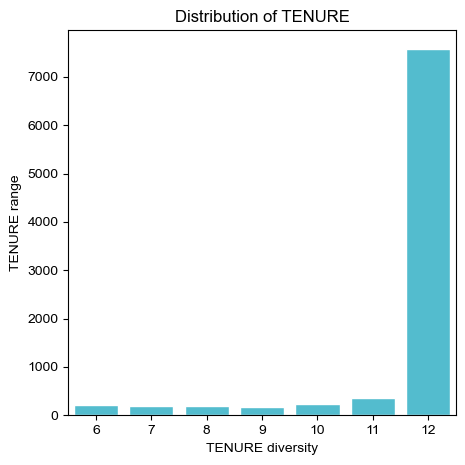

In [6]:
cor = '#3ecae3'
stack_cor = ['#e2fbff', '#b6f4ff', '#6ae8ff', '#3ecae3', '#1ab5d1', '#0097b2', '#007b91']
discrete_cols = ['TENURE']
fig, ax = plt.subplots(figsize = (5,5))
for col in discrete_cols:
    sns.set_style("whitegrid")
    sns.countplot(data = data, x = data[col].dropna(), color = cor)
    plt.title(f'Distribution of {col}')
    plt.xlabel(f'{col} diversity')
    plt.ylabel(f'{col} range')
    plt.show()

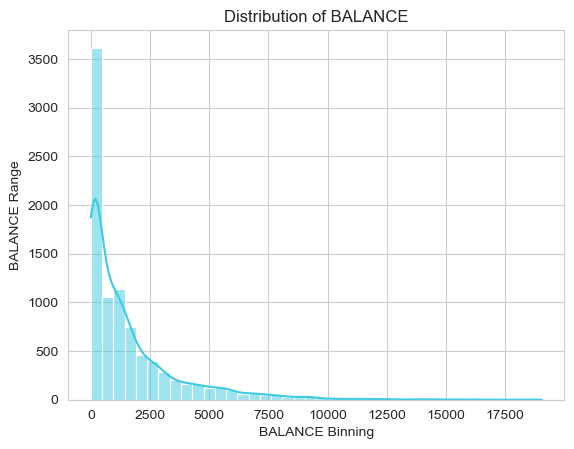

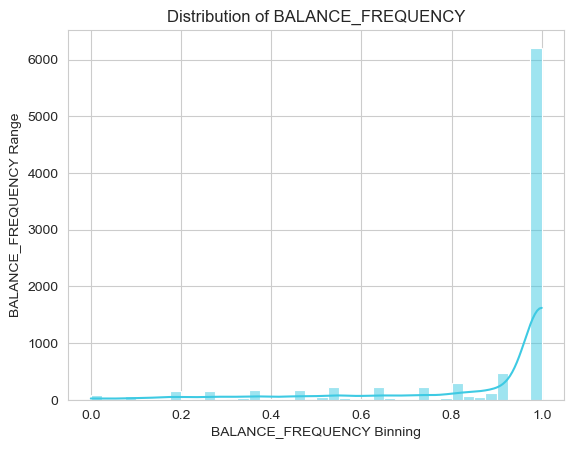

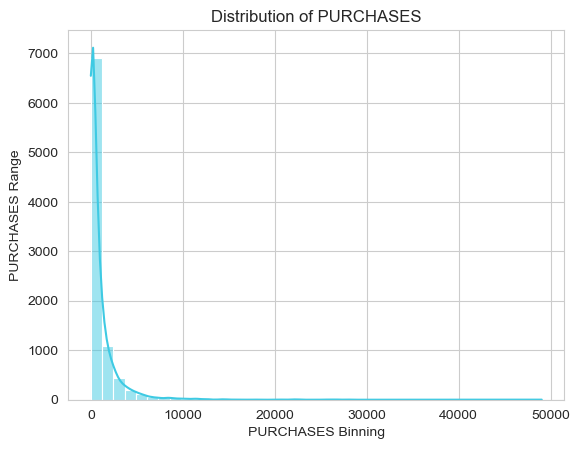

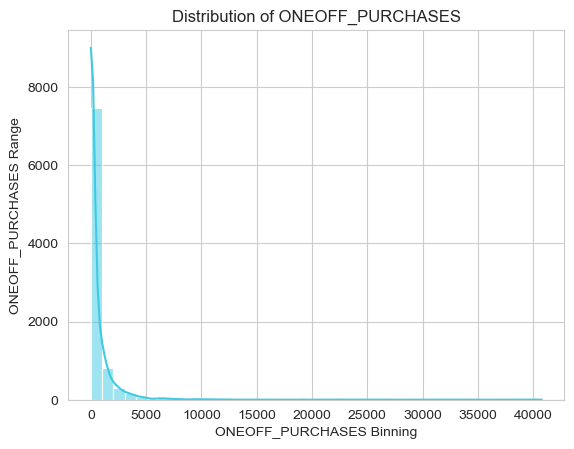

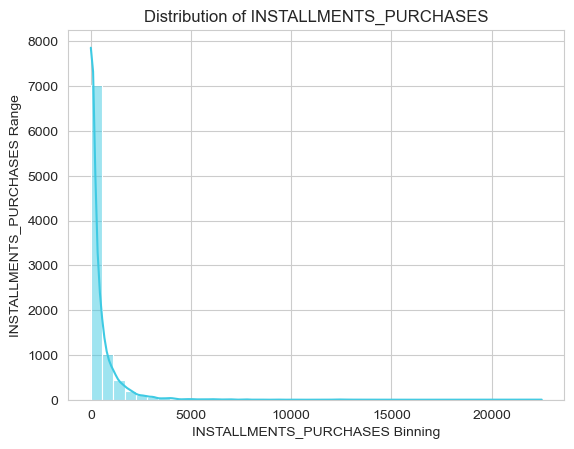

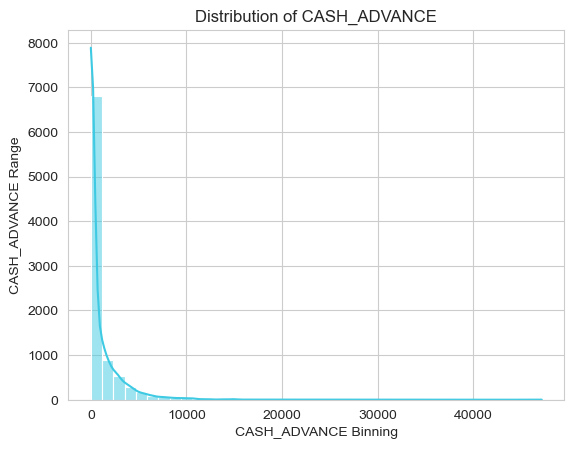

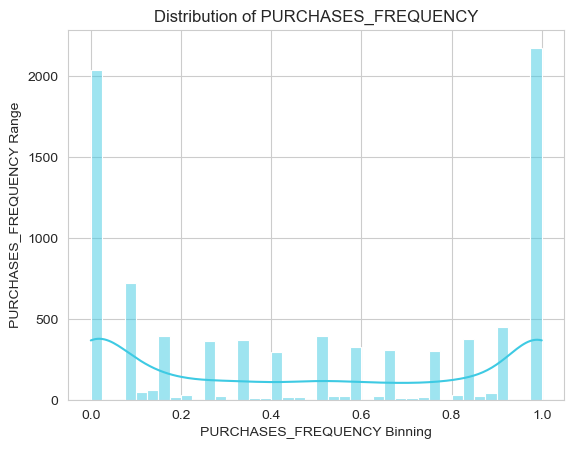

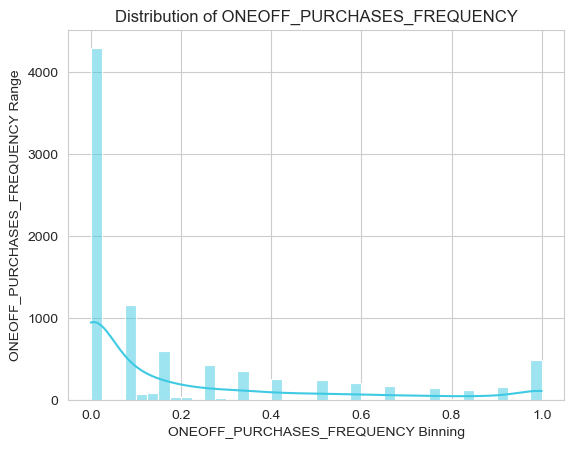

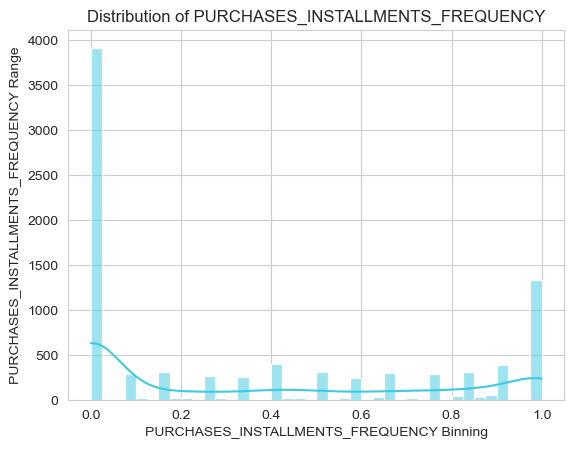

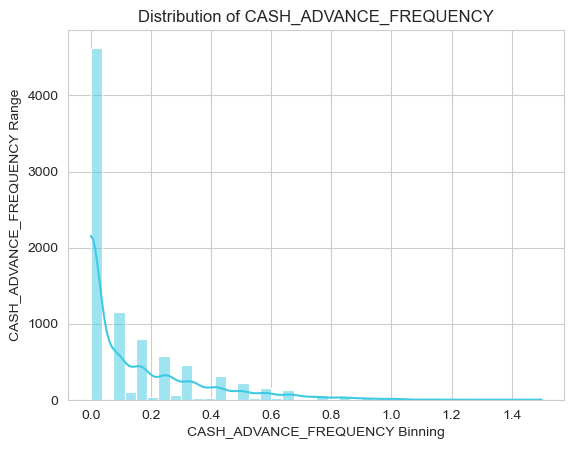

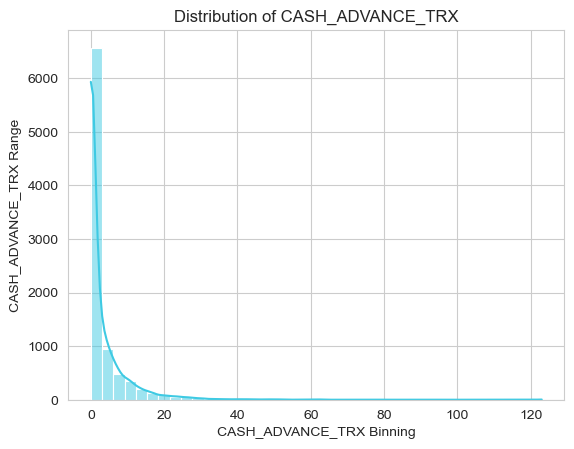

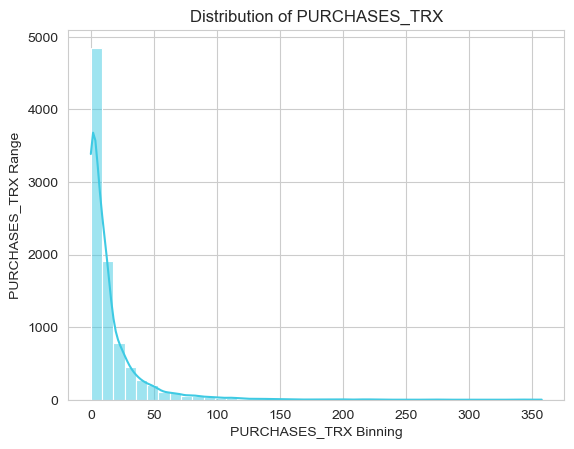

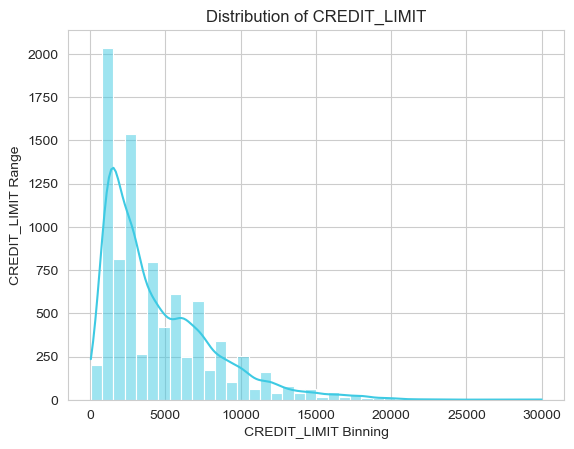

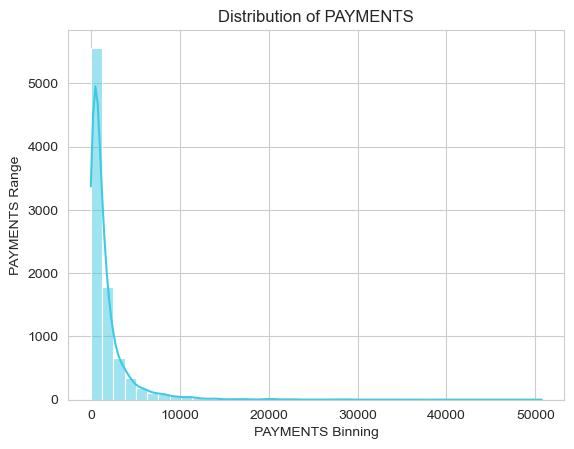

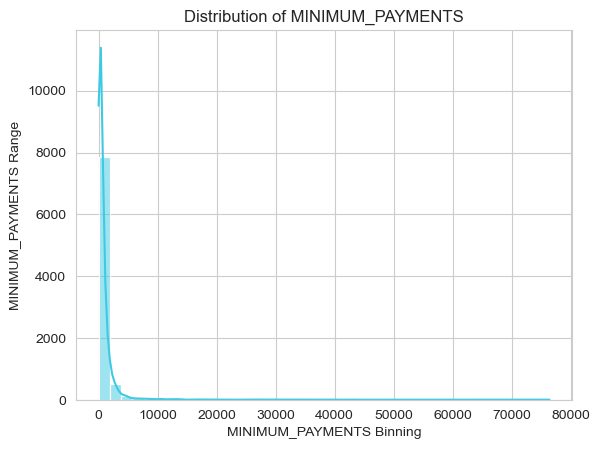

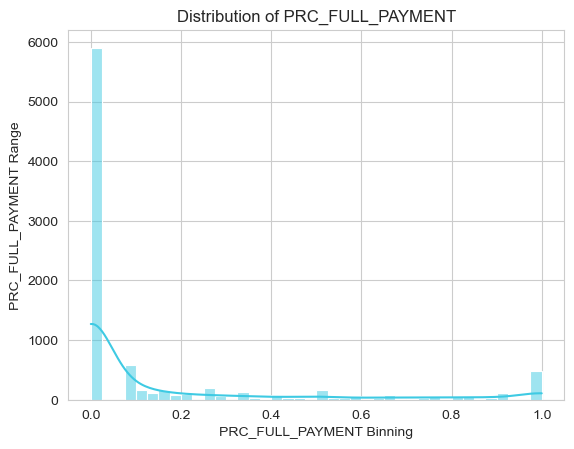

In [7]:
cont_cols = ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
            'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS',
            'PRC_FULL_PAYMENT']
for col in cont_cols:
    sns.set_style("whitegrid")
    sns.histplot(data = data, x = data[col].dropna(), bins = 40, color = cor, kde = True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(f'{col} Binning')
    plt.ylabel(f'{col} Range')
    plt.show()

<b><font size="5">Data Preparation</font></b><br><br>

In [8]:
print("----------------Handling missing values:-------------------")
# Deleting the one row with Credit Limit's null value
data_droped = data.dropna(subset = ['CREDIT_LIMIT'])
# Filling in the rows with Minimum Payments' null values with the median, since its distribution is skewed:
data_droped['MINIMUM_PAYMENTS'] = data_droped['MINIMUM_PAYMENTS'].fillna(data['MINIMUM_PAYMENTS'].median())
data_droped.info()

----------------Handling missing values:-------------------
<class 'pandas.core.frame.DataFrame'>
Index: 8949 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8949 non-null   object 
 1   BALANCE                           8949 non-null   float64
 2   BALANCE_FREQUENCY                 8949 non-null   float64
 3   PURCHASES                         8949 non-null   float64
 4   ONEOFF_PURCHASES                  8949 non-null   float64
 5   INSTALLMENTS_PURCHASES            8949 non-null   float64
 6   CASH_ADVANCE                      8949 non-null   float64
 7   PURCHASES_FREQUENCY               8949 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8949 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8949 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8949 non-null   float64
 11  CASH_ADVANCE_T

In [9]:
print("----------------Handling data types:-----------------------")
# Checking the pattern is fully repeated in Cust_ID variable
data_droped["CUST_ID"].str.match(r"^[A-Za-z]\d+$").all()

----------------Handling data types:-----------------------


True

In [10]:
data_droped["CUST_ID"] = data_droped["CUST_ID"].str[1:]
data_droped["CUST_ID"] = pd.to_numeric(data_droped["CUST_ID"])
# Float16: exp <=4, decimal digits <=3; Float32: exp <=38, decimal digits <=7; Float64: exp <=308, decimal digits <=16.
cols_to_uint8 = ['CASH_ADVANCE_TRX', 'TENURE']
cols_to_uint16 = ['CUST_ID', 'PURCHASES_TRX', 'CREDIT_LIMIT']
cols_to_float32 = ['BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
                   'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'PRC_FULL_PAYMENT']
for col in cols_to_uint8:
    data_droped[col] = data_droped[col].astype('uint8')
for col in cols_to_uint16:
    data_droped[col] = data_droped[col].astype('uint16')
for col in cols_to_float32:
    data_droped[col] = data_droped[col].astype('float32')

data_droped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8949 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8949 non-null   uint16 
 1   BALANCE                           8949 non-null   float64
 2   BALANCE_FREQUENCY                 8949 non-null   float32
 3   PURCHASES                         8949 non-null   float32
 4   ONEOFF_PURCHASES                  8949 non-null   float32
 5   INSTALLMENTS_PURCHASES            8949 non-null   float32
 6   CASH_ADVANCE                      8949 non-null   float64
 7   PURCHASES_FREQUENCY               8949 non-null   float32
 8   ONEOFF_PURCHASES_FREQUENCY        8949 non-null   float32
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8949 non-null   float32
 10  CASH_ADVANCE_FREQUENCY            8949 non-null   float32
 11  CASH_ADVANCE_TRX                  8949 non-null   uint8  
 12  PURCHASES_T

In [11]:
print("----------------Handling outliers:-----------------------")
print("There are no negative balances or impossible values, so we will not delete any observations.")
print("----------------Handling duplicates:-----------------------")
data_droped.drop_duplicates()
data_droped.info()

----------------Handling outliers:-----------------------
There are no negative balances or impossible values, so we will not delete any observations.
----------------Handling duplicates:-----------------------
<class 'pandas.core.frame.DataFrame'>
Index: 8949 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8949 non-null   uint16 
 1   BALANCE                           8949 non-null   float64
 2   BALANCE_FREQUENCY                 8949 non-null   float32
 3   PURCHASES                         8949 non-null   float32
 4   ONEOFF_PURCHASES                  8949 non-null   float32
 5   INSTALLMENTS_PURCHASES            8949 non-null   float32
 6   CASH_ADVANCE                      8949 non-null   float64
 7   PURCHASES_FREQUENCY               8949 non-null   float32
 8   ONEOFF_PURCHASES_FREQUENCY        8949 non-null   fl

In [14]:
corr_matrix = data_droped.corr().round(2)
print(corr_matrix)

                                  CUST_ID  BALANCE  BALANCE_FREQUENCY  \
CUST_ID                              1.00    -0.24              -0.11   
BALANCE                             -0.24     1.00               0.32   
BALANCE_FREQUENCY                   -0.11     0.32               1.00   
PURCHASES                           -0.14     0.18               0.13   
ONEOFF_PURCHASES                    -0.14     0.16               0.10   
INSTALLMENTS_PURCHASES              -0.08     0.13               0.12   
CASH_ADVANCE                        -0.08     0.50               0.10   
PURCHASES_FREQUENCY                 -0.02    -0.08               0.23   
ONEOFF_PURCHASES_FREQUENCY          -0.17     0.07               0.20   
PURCHASES_INSTALLMENTS_FREQUENCY     0.03    -0.06               0.18   
CASH_ADVANCE_FREQUENCY              -0.03     0.45               0.19   
CASH_ADVANCE_TRX                    -0.02     0.39               0.14   
PURCHASES_TRX                       -0.11     0.15 

In [16]:
from matplotlib.colors import ListedColormap
import seaborn as sns 
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

spearman correlation.


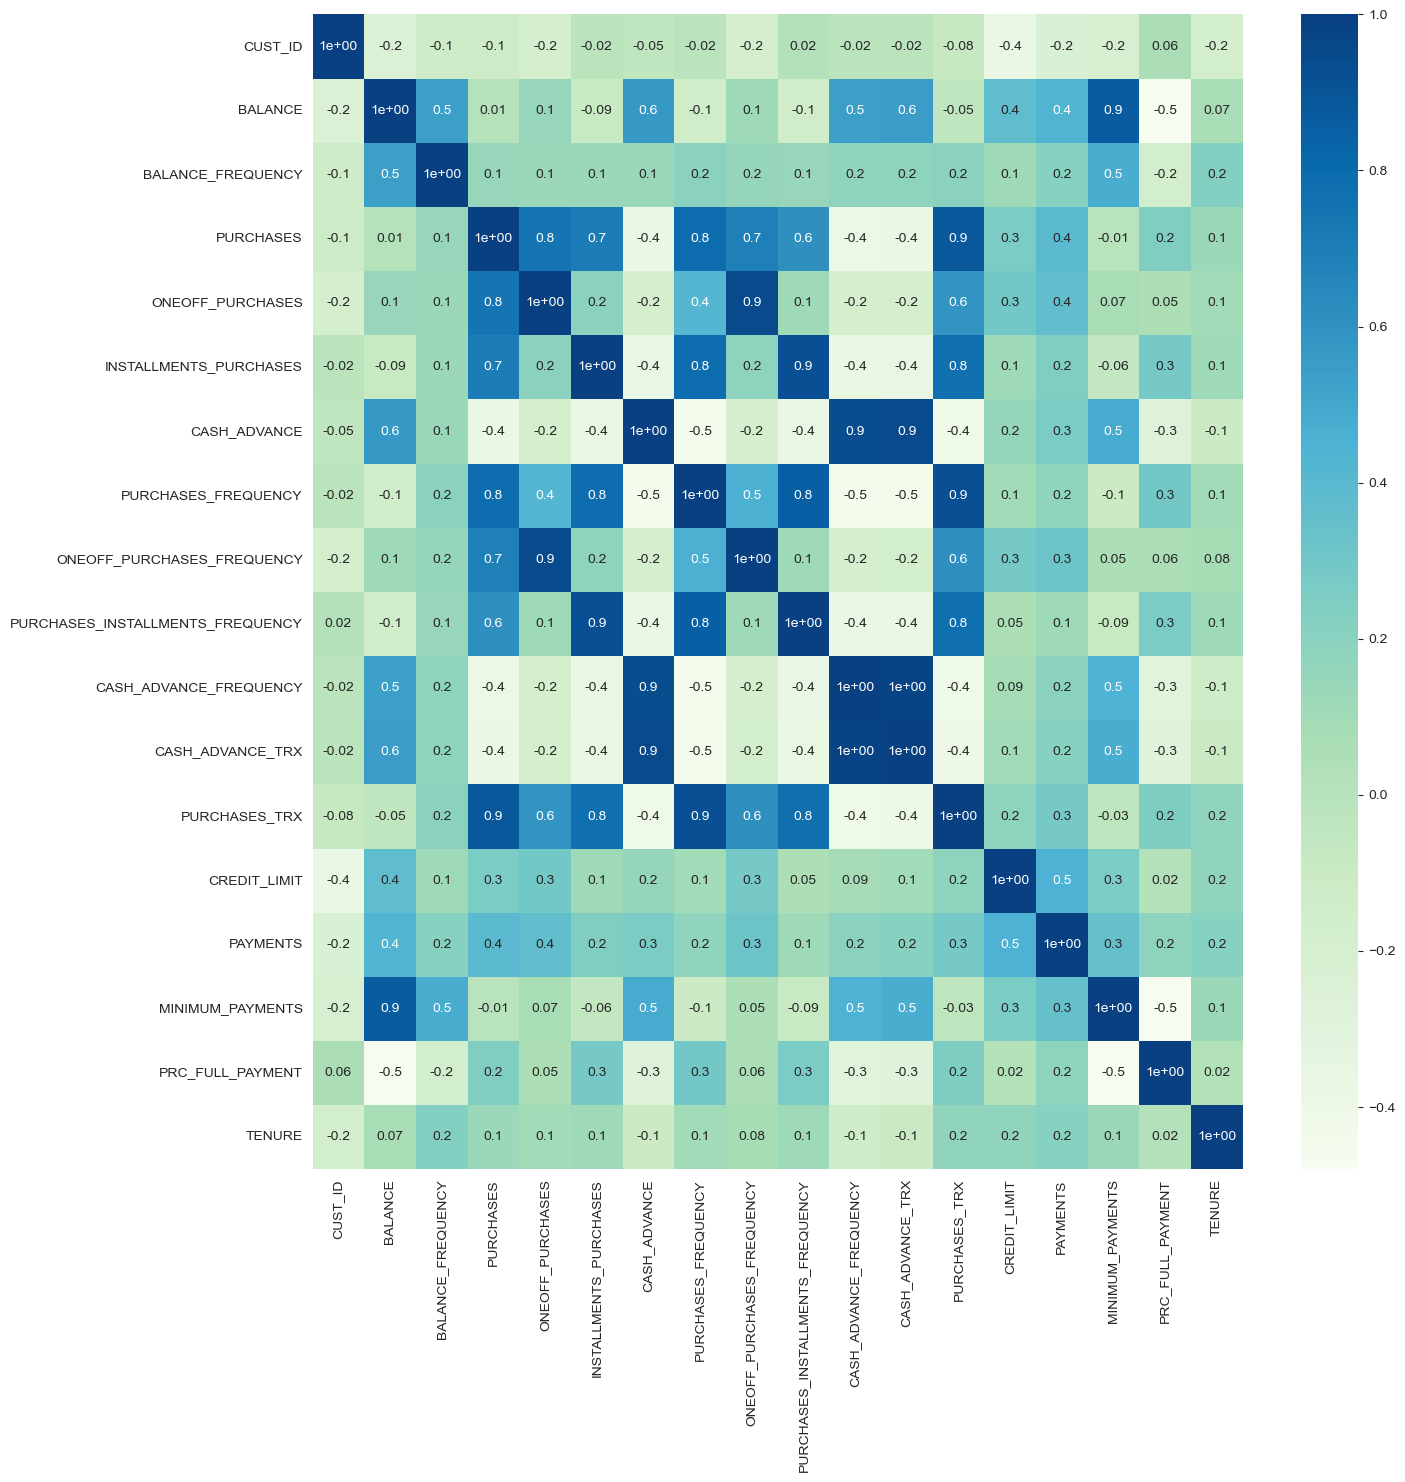

None

pearson correlation.


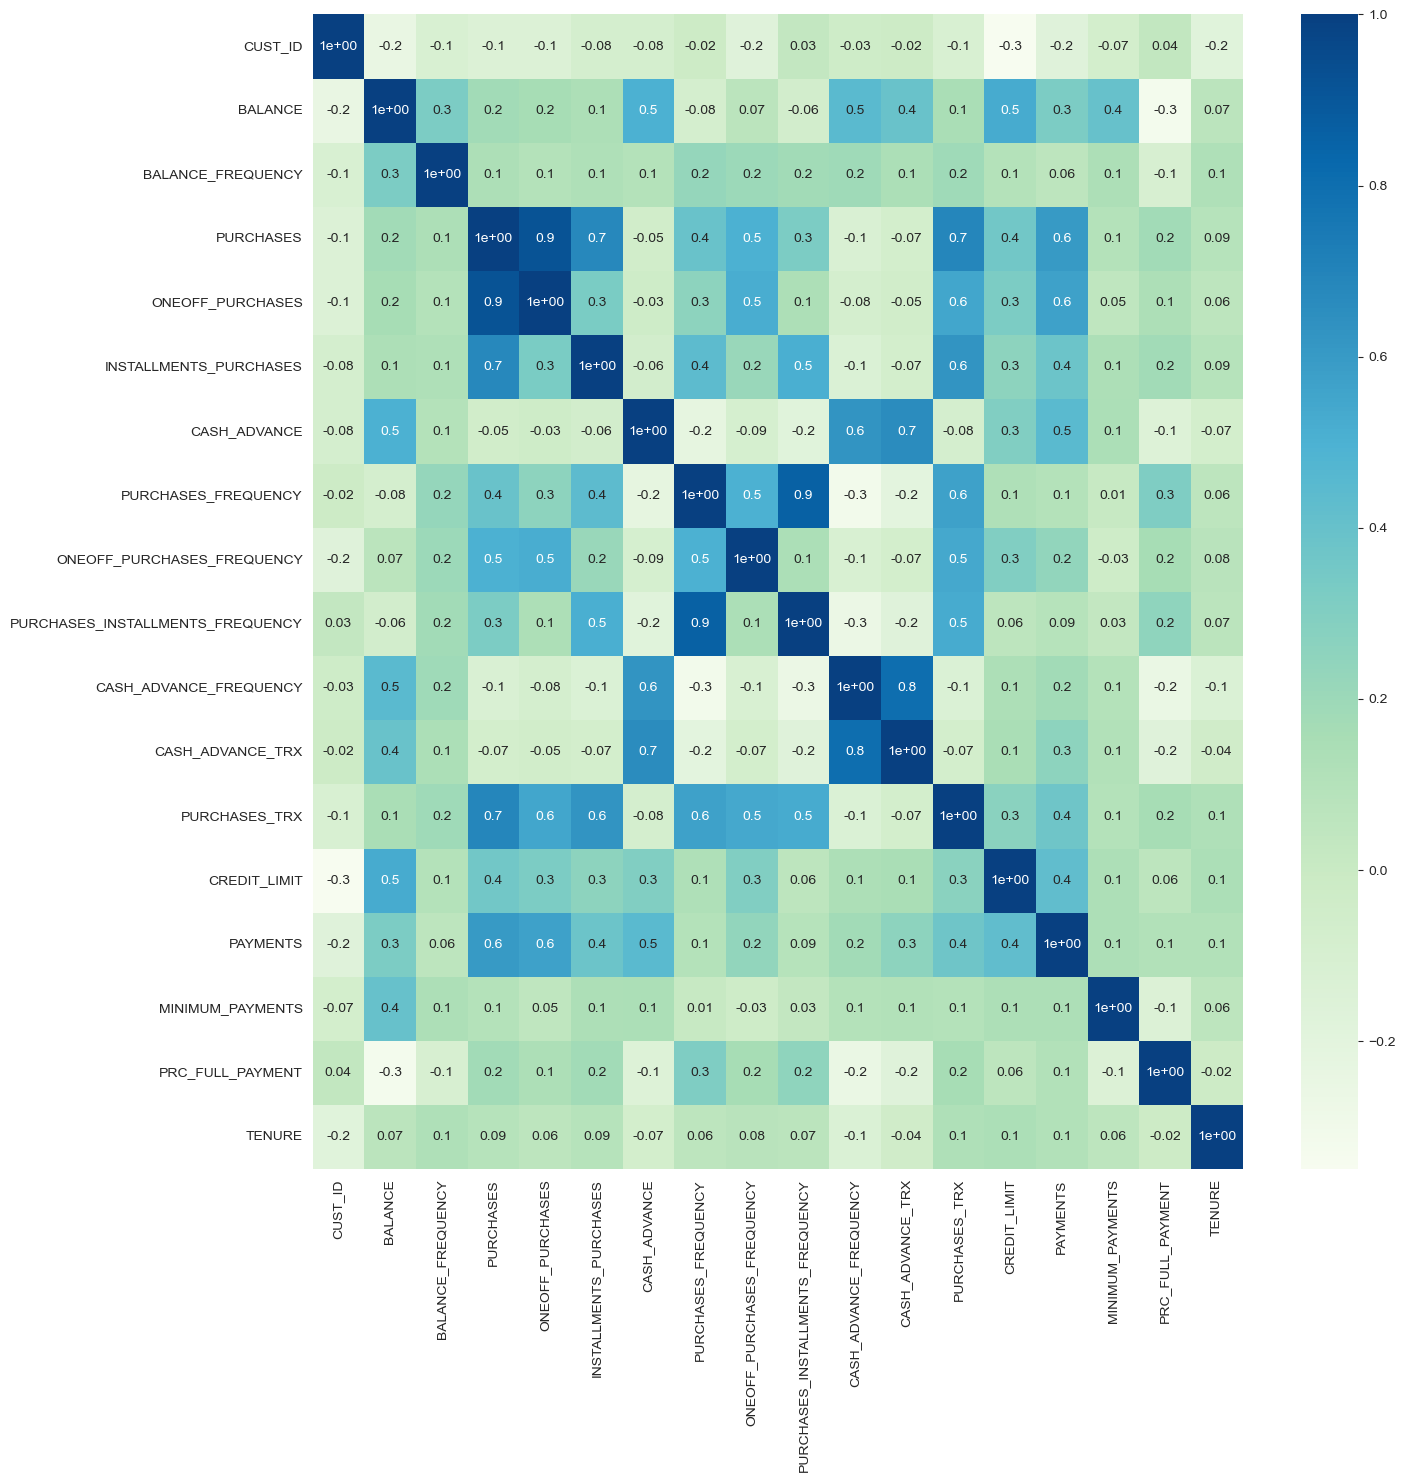

None

kendall correlation.


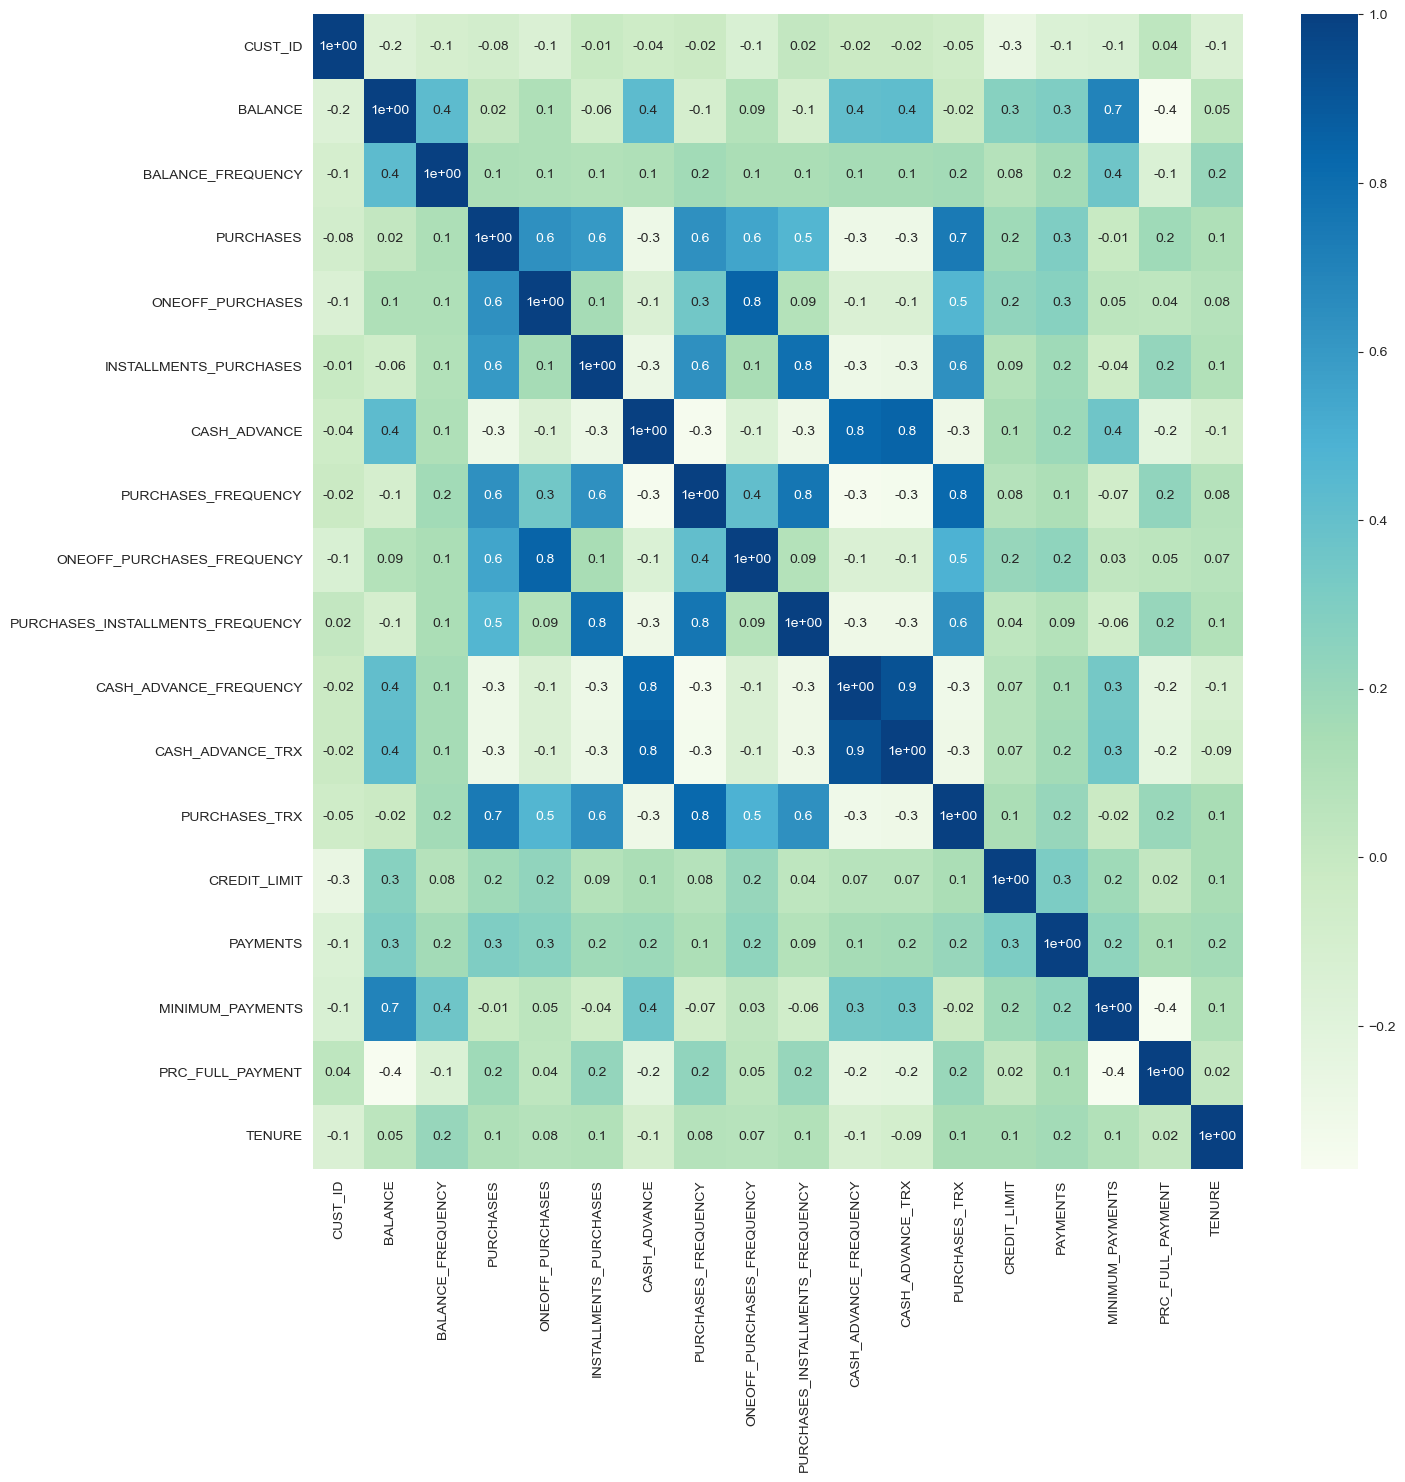

None

In [18]:
compile_corr_dic = []

def cor_heatmap(cor):
    plt.figure(figsize = (15,15))
    sns.heatmap(data = cor, annot = True, cmap = plt.cm.GnBu, fmt = '.1')
    plt.show()
    
for corr_type in ['spearman', 'pearson', 'kendall']:
    print(f'{corr_type} correlation.')
    corr_matrix = data_droped.corr(method = corr_type).round(2)
    display(cor_heatmap(corr_matrix))

In [ ]:
# |corr| < 0.8 !! join the two highly correlated vars or eliminate one of them

In [ ]:
# RobustScaler → less sensitive to extremes